# 01. Data Loading
## 📚 Learning Objectives

By completing this notebook, you will:
- Load data from CSV files with advanced options
- Load from Excel files and multiple sheets
- Load from JSON (including nested structures)
- Handle large files using chunking
- Implement error handling for robust data loading

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 1, lesson 01 "Data Loading and Exploration" — the same first step, now with Excel, nested JSON, chunking and error handling for files that misbehave.

**Used later in:** Course 05 — Unit 5, lesson 07, which loads files too large to fit in memory at all.

---


## 🎯 The case: how genetics renamed its genes to work around a spreadsheet

Ziemann, Eren and El-Osta examined **3,597 papers** in 18 genomics journals published
between 2005 and 2015, carrying **7,467 supplementary gene lists** made in Excel. In
**19.6%** of those papers — 704 articles — gene names had been silently corrupted by
default type inference. `SEPT2` had become the date **2-Sep**. `MARCH1` had become
**1-Mar**. RIKEN identifiers had become floating-point numbers. Nobody typed those values;
a loader guessed the type and rewrote the data (*Gene name errors are widespread in the
scientific literature*, Genome Biology 17:177, 2016).

The ending is the part students remember: fixing every lab's workflow proved harder than
**renaming the genes**. In 2020 the HUGO Gene Nomenclature Committee reissued the symbols —
`SEPT1` became `SEPTIN1`, `MARCH1` became `MARCHF1` — so that a spreadsheet would stop
eating them. A follow-up scan of 2014–2020 articles (Abeysooriya et al., *Gene name errors:
lessons not learned*, PLOS Computational Biology 17(7): e1008984, 2021) found errors in
**30.9%** of articles carrying supplementary Excel gene lists — higher than the 2016 figure
partly because the newer scanner also catches gene names converted to five-digit internal
date codes.

**What goes wrong without this lesson.** Loading is where a file stops being bytes and
becomes typed values, and every default in that step is a guess. You will watch two of
those guesses go wrong below: the border-crossing `Date` column arrives as `object` — plain
text, not a date — unless you pass `parse_dates`, and `Pclass` arrives as `int64` when
`category` costs a fifth of the memory. Neither raises an error. Neither is visible unless
you look.


**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## The Story: Getting Your Ingredients

Imagine you're cooking. **Before** you can clean and prepare ingredients, you need to get 
them from the store - know what's available, handle different packages, check if items 
are missing. **After** getting everything loaded, you can start preparing!

Same with data science: **Before** cleaning and analyzing, we load data from files - know 
file formats, handle different sources, check for errors. **After** loading successfully, 
we can start cleaning!

---

## Why Advanced Data Loading Matters

Advanced loading techniques are essential because:
- **Multiple Formats**: Real data comes in CSV, Excel, JSON, databases
- **Large Files**: Need chunking to load huge datasets that don't fit in memory
- **Error Handling**: Files may be missing, corrupted, or have encoding issues
- **Performance**: Correct loading options make your code faster

## Learning Objectives
1. Load data from CSV files with advanced options
2. Load data from Excel files and multiple sheets
3. Load data from JSON files (including nested structures)
4. Handle large files using chunking techniques
5. Implement error handling for robust data loading


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries: pandas
- File paths: CSV, Excel, JSON (notebook creates sample files in `unit2-cleaning/examples/`)

**Outputs:** What you'll see when you run the cells

- Loaded DataFrames (sample_data, large_data chunked)
- Printed success messages and basic stats

---

In [1]:
# WHAT: Import the file-handling toolkit - pandas for tables, json and os/pathlib for files.
# WHY: Loading is the first step of every project; these libraries cover the three most common formats (CSV, Excel, JSON).

# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import json
import os
from pathlib import Path

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - pandas: Load data from CSV, Excel, JSON files")
print("   - numpy: Numeric helpers (NaN checks, dtypes)")
print("   - json: Handle JSON file formats")
print("   - os/pathlib: Handle file paths and directories")

print("\n" + "=" * 70)
print("=" * 70)
print("\n📚 Prerequisites: Unit 1 completed, pandas DataFrame knowledge")
print("🔗 This is the FIRST example in Unit 2 - foundation for data cleaning")
print("🎯 Goal: Master loading data from multiple sources and formats\n")


✅ Libraries imported successfully!

📚 What each library does:
   - pandas: Load data from CSV, Excel, JSON files
   - numpy: Numeric helpers (NaN checks, dtypes)
   - json: Handle JSON file formats
   - os/pathlib: Handle file paths and directories


📚 Prerequisites: Unit 1 completed, pandas DataFrame knowledge
🔗 This is the FIRST example in Unit 2 - foundation for data cleaning
🎯 Goal: Master loading data from multiple sources and formats



## Part 1: Loading from CSV Files

**BEFORE**: You know basic CSV loading but not advanced options.

**AFTER**: You'll load CSV files with encoding, missing value handling, and date parsing!

**Why this matters**: Real CSV files have encoding issues, missing values, and date formats!

## Step 1: Loading from CSV

**BEFORE**: We know `pd.read_csv(path)` and nothing else.

**AFTER**: We'll load two real CSV files and see what the *default* options quietly
get wrong!

**The data**: the Titanic passenger manifest (891 rows, real gaps) and the US border
crossing log (346,733 rows, a real date column).


In [2]:
# WHAT: Load two real CSV files, first with defaults and then with explicit options.
# WHY: Real CSV loading needs NA markers, dtypes, and date parsing - defaults silently give you strings where you wanted dates.

print("\n1. Loading from CSV")
print("-" * 70)

# Both datasets live once in the repository and are shared across courses.
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load, path as dataset_path
# -------------------------------------------------------------------------------------
# dataset_path() hands back a real file path, so every pd.read_csv below is the
# genuine article - this notebook is about read_csv's options, not about loading.
csv_file = dataset_path("titanic")

print("\nLoading CSV with default options")
df1 = pd.read_csv(csv_file)
print(f"Shape: {df1.shape}")
print(f"Missing values pandas found on its own: {df1.isnull().sum().sum()}")
print("   pandas already treats an EMPTY FIELD as NaN - that is the default.")

print("\nLoading CSV with explicit options")
# na_values: extra strings that should also count as missing. Datasets in the wild
#   write 'NULL', 'null', 'N/A', '-' and similar - pandas will NOT guess those.
# dtype: force a column's type instead of letting pandas infer it.
df2 = pd.read_csv(
    csv_file,
    encoding='utf-8',
    na_values=['', 'NULL', 'null', 'N/A', '?'],
    dtype={'Pclass': 'category', 'Survived': 'int8'},
)
print(f"Shape: {df2.shape}")
print(f"Pclass dtype: {df2['Pclass'].dtype}  (category uses less memory than object)")
print(f"Pclass column memory - default int64: "
      f"{df1['Pclass'].memory_usage(deep=True) / 1024:.1f} KB"
      f" -> category: {df2['Pclass'].memory_usage(deep=True) / 1024:.1f} KB")
print(f"Whole frame - defaults: {df1.memory_usage(deep=True).sum() / 1024:.1f} KB"
      f" -> with dtypes: {df2.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("   The whole-frame saving is small here because the text columns (Name,")
print("   Ticket, Cabin) dominate. At millions of rows the same trick matters a lot.")

print("\nWhy parse_dates matters (border crossing log)")
# prefer="sample" so this prints the same numbers on every machine, whether or not
# the 37 MB original has been downloaded.
border_file = dataset_path("border_crossing_data", prefer="sample")

# Without parse_dates the Date column is just text - you cannot sort or resample it.
b_default = pd.read_csv(border_file, usecols=['Date', 'Value'], nrows=5000)
print(f"   Default dtype of 'Date': {b_default['Date'].dtype}  <- text, not a date!")

# With an explicit format, pandas builds real timestamps (and does it faster).
b_parsed = pd.read_csv(border_file, usecols=['Date', 'Value'], nrows=5000,
                       parse_dates=['Date'], date_format='%m/%d/%Y %I:%M:%S %p')
print(f"   With parse_dates:        {b_parsed['Date'].dtype}  <- now .dt works")
print(f"   Earliest record in this sample: {b_parsed['Date'].min():%Y-%m-%d}")



1. Loading from CSV
----------------------------------------------------------------------
titanic: full file, 891 rows.

Loading CSV with default options
Shape: (891, 12)
Missing values pandas found on its own: 866
   pandas already treats an EMPTY FIELD as NaN - that is the default.

Loading CSV with explicit options
Shape: (891, 12)
Pclass dtype: category  (category uses less memory than object)
Pclass column memory - default int64: 7.1 KB -> category: 1.3 KB
Whole frame - defaults: 285.6 KB -> with dtypes: 273.7 KB
   The whole-frame saving is small here because the text columns (Name,
   Ticket, Cabin) dominate. At millions of rows the same trick matters a lot.

Why parse_dates matters (border crossing log)
border_crossing_data: bundled 43,818-row sample of the 346,733-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified by (month, crossing type): all 279 m

## Part 2: Loading from Excel Files

**BEFORE**: You can load CSV but not Excel files.

**AFTER**: You'll load Excel files and handle multiple sheets!

**Why this matters**: Many organizations use Excel - you need to handle .xlsx files!

## Step 2: Loading from Excel

**BEFORE**: We have a real CSV but business colleagues send spreadsheets.

**AFTER**: We'll write the real data to a two-sheet workbook and load the sheets back!


In [3]:
# WHAT: Write a two-sheet Excel workbook from the real manifest, list its sheets, and load them one-by-one and all at once.
# WHY: Spreadsheets are how business data usually arrives - sheet_name (str, list, or None) covers every loading case.

print("\n\n2. Loading from Excel")
print("-" * 70)
excel_file = 'titanic_workbook.xlsx'

# Sheet 1: the raw passenger rows we just loaded.
# Sheet 2: a summary derived FROM that same real data - exactly how a real
# workbook grows a "summary" tab next to its "data" tab.
df_class_summary = (df1.groupby('Pclass')
                       .agg(passengers=('PassengerId', 'count'),
                            mean_fare=('Fare', 'mean'),
                            survival_rate=('Survived', 'mean'))
                       .round(3)
                       .reset_index())

with pd.ExcelWriter(excel_file) as writer:
    df1.to_excel(writer, index=False, sheet_name='Passengers')
    df_class_summary.to_excel(writer, index=False, sheet_name='ClassSummary')
print(f"✓ Created Excel file with 2 sheets: {excel_file}")

# Discover which sheets a workbook contains
sheets = pd.ExcelFile(excel_file).sheet_names
print(f"\nSheets in the workbook: {sheets}")

# Load a sheet by name
print("\nLoading sheet by name ('Passengers'):")
df_excel = pd.read_excel(excel_file, sheet_name='Passengers')
print(f"Shape: {df_excel.shape}")
print(f"Columns: {list(df_excel.columns)}")

# Load a different sheet
print("\nLoading the second sheet ('ClassSummary'):")
df_summary = pd.read_excel(excel_file, sheet_name='ClassSummary')
print(df_summary.to_string(index=False))

# Load ALL sheets at once: sheet_name=None returns a dict of DataFrames
print("\nLoading ALL sheets at once (sheet_name=None):")
all_sheets = pd.read_excel(excel_file, sheet_name=None)
for name, sheet_df in all_sheets.items():
    print(f"  '{name}': {sheet_df.shape[0]} rows x {sheet_df.shape[1]} columns")

print("\n⚠ Note what Excel round-tripping did NOT preserve: the 'category' dtype")
print("  and the int8 we set above come back as plain object/int64. Excel stores")
print("  values, not pandas types.")




2. Loading from Excel
----------------------------------------------------------------------
✓ Created Excel file with 2 sheets: titanic_workbook.xlsx

Sheets in the workbook: ['Passengers', 'ClassSummary']

Loading sheet by name ('Passengers'):
Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Loading the second sheet ('ClassSummary'):
 Pclass  passengers  mean_fare  survival_rate
      1         216     84.155          0.630
      2         184     20.662          0.473
      3         491     13.676          0.242

Loading ALL sheets at once (sheet_name=None):


  'Passengers': 891 rows x 12 columns
  'ClassSummary': 3 rows x 4 columns

⚠ Note what Excel round-tripping did NOT preserve: the 'category' dtype
  and the int8 we set above come back as plain object/int64. Excel stores
  values, not pandas types.


## Part 3: Loading from JSON Files

**BEFORE**: You can load CSV/Excel but not JSON (API data).

**AFTER**: You'll load JSON files and handle nested structures!

**Why this matters**: APIs return JSON - web data is often in JSON format!

## Step 3: Loading from JSON

**BEFORE**: We have a flat table, but web APIs answer in nested JSON.

**AFTER**: We'll export the real passenger records into a nested JSON document and
flatten them back with `json_normalize`!


In [4]:
# WHAT: Write a nested JSON document built from the real manifest, then load it with read_json and flatten it with json_normalize.
# WHY: APIs return nested JSON; json_normalize is the standard way to turn nested records into a flat table.

print("\n\n3. Loading from JSON")
print("-" * 70)

# Build the kind of document a passenger API would return: a top-level object with
# metadata plus a nested list of records. Every value comes from the real file.
first_20 = df1.head(20)
json_data = {
    'source': 'titanic.csv',
    'record_count': int(len(first_20)),
    'passengers': [
        {
            'id': int(row.PassengerId),
            'name': row.Name,
            'ticket': {'pclass': int(row.Pclass), 'fare': float(row.Fare)},
            # A missing Age must become JSON null, not the string 'nan'.
            'age': None if pd.isna(row.Age) else float(row.Age),
        }
        for row in first_20.itertuples()
    ],
}
json_file = 'titanic_sample.json'
with open(json_file, 'w') as f:
    json.dump(json_data, f, indent=2)
print(f"✓ Created JSON file from the real manifest: {json_file}")

# read_json on this document gives you the OUTER object - note the awkward shape.
print("\nLoading JSON file with pd.read_json")
df_json = pd.read_json(json_file)
print(f"Shape: {df_json.shape}")
print(f"Columns: {list(df_json.columns)}  <- 'passengers' is a column of dicts")

# json_normalize walks into the nested list and flattens the sub-objects.
print("\nFlattening with pd.json_normalize(record_path='passengers')")
df_json2 = pd.json_normalize(json_data, record_path='passengers')
print(f"Normalized JSON shape: {df_json2.shape}")
print(f"Columns: {list(df_json2.columns)}  <- 'ticket.pclass' came from the nesting")
print(df_json2.head(3).to_string(index=False))
print(f"\nMissing ages survived the round trip as NaN: {df_json2['age'].isna().sum()}")




3. Loading from JSON
----------------------------------------------------------------------
✓ Created JSON file from the real manifest: titanic_sample.json

Loading JSON file with pd.read_json
Shape: (20, 3)
Columns: ['source', 'record_count', 'passengers']  <- 'passengers' is a column of dicts

Flattening with pd.json_normalize(record_path='passengers')
Normalized JSON shape: (20, 5)
Columns: ['id', 'name', 'age', 'ticket.pclass', 'ticket.fare']  <- 'ticket.pclass' came from the nesting
 id                                                name  age  ticket.pclass  ticket.fare
  1                             Braund, Mr. Owen Harris 22.0              3       7.2500
  2 Cumings, Mrs. John Bradley (Florence Briggs Thayer) 38.0              1      71.2833
  3                              Heikkinen, Miss. Laina 26.0              3       7.9250

Missing ages survived the round trip as NaN: 3


## Part 4: Handling Large Files - Chunking

**BEFORE**: You can load small files but not large ones (memory issues).

**AFTER**: You'll load huge files in chunks without running out of memory!

**Why this matters**: Large datasets don't fit in memory - chunking is essential!

## Step 4: Chunking Large Files

**BEFORE**: Large files crash our program (out of memory).

**AFTER**: We'll stream a real transaction file through memory in chunks and compute a
statistic without ever holding the whole thing!

**The data**: `creditcard_fraud.csv` — 284,807 real card transactions, of which a tiny
number are fraud. The full file is **151 MB and is not in this repository**, so what runs
here is the bundled **16,000-row sample** (4.7 MB), drawn to hold the fraud rate at 0.175%.
Every number below is the sample's. The chunking code is character-for-character what you
would run on the 151 MB original.


In [5]:
# WHAT: Stream a real card-transaction file in 2,000-row chunks, accumulating a result per chunk.
# WHY: Chunking keeps memory bounded - it is how you process files bigger than RAM.
# NOTE: the full creditcard_fraud.csv is 151 MB / 284,807 rows and is NOT in the repository.
#       prefer="sample" streams the 16,000-row copy that ships with it, so the numbers
#       below are identical on every machine. The technique is the one you would use on
#       the 151 MB file; only the row count differs.

print("\n\n4. Handling Large Files (Chunking)")
print("-" * 70)

large_csv = dataset_path("creditcard_fraud", prefer="sample")
file_mb = os.path.getsize(large_csv) / 1e6
print(f"File on disk: {large_csv.name} ({file_mb:.1f} MB)")

# chunksize turns read_csv into an ITERATOR of DataFrames instead of one big frame.
# Only one chunk is in memory at a time - that is the whole point.
chunk_size = 2000
n_rows = 0
n_fraud = 0
total_amount = 0.0
peak_chunk_mb = 0.0
# Record one row per chunk so we can PLOT the stream after the loop finishes.
chunk_log = []

print("\nStreaming the file in chunks (never loading it whole)")
for i, chunk in enumerate(pd.read_csv(large_csv, chunksize=chunk_size,
                                      usecols=['Amount', 'Class']), start=1):
    n_rows += len(chunk)
    n_fraud += int((chunk['Class'] == 1).sum())
    total_amount += float(chunk['Amount'].sum())
    peak_chunk_mb = max(peak_chunk_mb, chunk.memory_usage(deep=True).sum() / 1e6)
    chunk_log.append({'chunk': i, 'cum_rows': n_rows, 'cum_fraud': n_fraud,
                      'held_mb': chunk.memory_usage(deep=True).sum() / 1e6})
    print(f"  Chunk {i:>2}: {len(chunk):>6,} rows | running fraud count: {n_fraud}")

print(f"\n✓ Total rows processed: {n_rows:,}")
print(f"✓ Fraudulent transactions found: {n_fraud:,} ({n_fraud / n_rows * 100:.3f}%)")
print(f"✓ Total amount across all transactions: {total_amount:,.2f}")
print(f"✓ Largest single chunk held in memory: {peak_chunk_mb:.2f} MB")
print(f"   That is the memory ceiling - not the {file_mb:.1f} MB of the file,")
print("   and not the 151 MB of the full original either.")
print("   Two columns instead of 31 (usecols) is why even the chunks are small.")




4. Handling Large Files (Chunking)
----------------------------------------------------------------------
creditcard_fraud: bundled 16,000-row sample of the 284,807-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified so the fraud rate stays 0.175% (28 fraud rows) against 0.173% in the full file; V1-V28 and Amount rounded to 6 decimals.
File on disk: creditcard_fraud.sample.csv (4.7 MB)

Streaming the file in chunks (never loading it whole)
  Chunk  1:  2,000 rows | running fraud count: 6
  Chunk  2:  2,000 rows | running fraud count: 10
  Chunk  3:  2,000 rows | running fraud count: 12
  Chunk  4:  2,000 rows | running fraud count: 17
  Chunk  5:  2,000 rows | running fraud count: 20
  Chunk  6:  2,000 rows | running fraud count: 22
  Chunk  7:  2,000 rows | running fraud count: 25
  Chunk  8:  2,000 rows | running fraud count: 28

✓ Total rows processed: 16,0

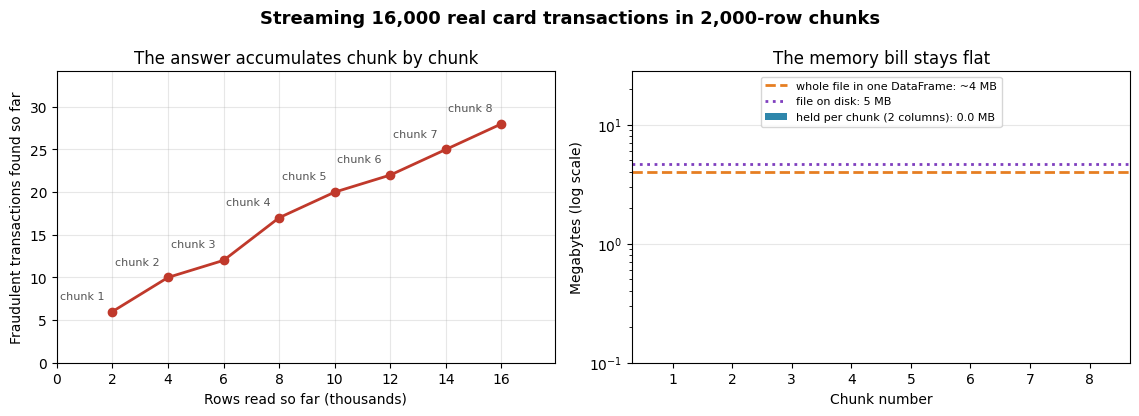


Step table (one row per chunk):
chunk  rows so far  frauds so far   MB held
    1        2,000              6      0.03
    2        4,000             10      0.03
    3        6,000             12      0.03
    4        8,000             17      0.03
    5       10,000             20      0.03
    6       12,000             22      0.03
    7       14,000             25      0.03
    8       16,000             28      0.03

Peak memory held: 0.0 MB — 124x smaller than loading the file whole (~4 MB).


In [6]:
# WHAT: Plot the two things the loop above just proved - the answer accumulating, and memory staying flat.
# WHY: The per-chunk numbers scrolled past one line at a time; one picture shows the whole trade at once.

import matplotlib.pyplot as plt

# How much memory would the WHOLE file cost if we loaded it in one go, all 31 columns?
# Measure 5,000 real rows and scale up - arithmetic on real bytes, not a guess.
probe = pd.read_csv(large_csv, nrows=5000)
full_frame_mb = probe.memory_usage(deep=True).sum() / len(probe) * n_rows / 1e6

steps      = [r['chunk'] for r in chunk_log]
cum_krows  = [r['cum_rows'] / 1000 for r in chunk_log]
cum_fraud  = [r['cum_fraud'] for r in chunk_log]
held_mb    = [r['held_mb'] for r in chunk_log]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.5, 4.2))

# LEFT: what you GAIN as the stream advances. One dot per chunk, labelled with its number.
axL.plot(cum_krows, cum_fraud, marker='o', color='#c0392b', linewidth=2, zorder=3)
for r, x, y in zip(steps, cum_krows, cum_fraud):
    axL.annotate(f'chunk {r}', (x, y), textcoords='offset points', xytext=(-6, 9),
                 fontsize=8, ha='right', color='#555555')
axL.set_xlabel('Rows read so far (thousands)')
axL.set_ylabel('Fraudulent transactions found so far')
axL.set_title('The answer accumulates chunk by chunk')
axL.set_xlim(0, max(cum_krows) * 1.12)
axL.set_ylim(0, max(cum_fraud) * 1.22)
axL.grid(alpha=0.3)

# RIGHT: what you PAY. Bars = memory actually held; dashed lines = the two alternatives.
axR.bar(steps, held_mb, color='#2e86ab', width=0.6,
        label=f'held per chunk (2 columns): {max(held_mb):.1f} MB')
axR.axhline(full_frame_mb, color='#e67e22', linestyle='--', linewidth=2,
            label=f'whole file in one DataFrame: ~{full_frame_mb:.0f} MB')
axR.axhline(file_mb, color='#7f3fbf', linestyle=':', linewidth=2,
            label=f'file on disk: {file_mb:.0f} MB')
axR.set_yscale('log')
axR.set_ylim(0.1, file_mb * 6)
axR.set_xlabel('Chunk number')
axR.set_ylabel('Megabytes (log scale)')
axR.set_title('The memory bill stays flat')
axR.legend(fontsize=8, loc='upper center')
axR.grid(alpha=0.3, axis='y')

fig.suptitle(f'Streaming {n_rows:,} real card transactions in {chunk_size:,}-row chunks',
             fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# The same picture as a table, so the numbers are on the record too.
print("\nStep table (one row per chunk):")
print(f"{'chunk':>5} {'rows so far':>12} {'frauds so far':>14} {'MB held':>9}")
for r in chunk_log:
    print(f"{r['chunk']:>5} {r['cum_rows']:>12,} {r['cum_fraud']:>14,} {r['held_mb']:>9.2f}")
print(f"\nPeak memory held: {max(held_mb):.1f} MB — "
      f"{full_frame_mb / max(held_mb):.0f}x smaller than loading the file whole "
      f"(~{full_frame_mb:.0f} MB).")


**Read the figure.** *Left* — one dot per chunk, plotted where the running fraud count
stood after that chunk was consumed. The line only ever climbs: each chunk contributes its
own frauds and nothing already counted is revisited. That is what "accumulable" means, and
it is exactly why chunking answers *this* question.

*Right* — the blue bars are the memory actually held while the loop ran, one bar per chunk.
All eight are identical (2,000 rows each), because 16,000 divides exactly by 2,000. The loop
never grows. The orange dashed line is what the same 16,000 rows would cost as a single
DataFrame with all 31 columns, and the purple dotted line is the 4.7 MB file on disk. The y
axis is **logarithmic**, so read the gap carefully: the bars are not a little lower than the
lines, they are more than a hundred times lower. On the 151 MB original the bars would sit
at exactly the same height — that is the point of the technique.

Put the panels together and you have the whole argument for streaming: the left panel is
the answer you would have got from the whole file, and the right panel is what it cost.


## 💬 Discuss

You just streamed a real transaction file in 2,000-row chunks and found **28 frauds in
16,000 transactions (0.175%)** while never holding more than **0.03 MB** in memory. (The
full file behind that sample holds 492 frauds in 284,807 transactions, 0.173% — the sample
was drawn to keep that rate.)

1. Chunking worked here because the answer — a count and a sum — can be accumulated one
   chunk at a time. Name a question about this same file that chunking **cannot** answer
   this way, and say what you would do instead.
2. The chunk loop passed `usecols` to read 2 of 31 columns. Suppose a colleague argues
   "just load the whole file, the machine has 32 GB". Give the strongest argument for their
   position and the strongest against it. Which wins on a laptop? On a shared server that
   six analysts use at once?
3. `safe_load_csv` catches a missing file and prints a message, and the pipeline keeps
   going. For a nightly job that feeds a fraud dashboard, is "keep going with 5 of the 6
   input files" the right behaviour? Say who finds out, and when.


## Part 5: Error Handling

**BEFORE**: Your code crashes when files are missing or corrupted.

**AFTER**: You'll handle errors gracefully and keep your code running!

**Why this matters**: Real-world files are missing, corrupted, or have wrong formats!

## Step 5: Robust Error Handling

**BEFORE**: Missing files cause crashes.

**AFTER**: We'll create functions that handle errors gracefully!

In [7]:
# WHAT: Define safe_load_csv - a loader wrapped in try/except for the common failure modes.
# WHY: Production code must survive missing or empty files; catching specific exceptions gives useful messages instead of crashes.

def safe_load_csv(filepath, **kwargs):
    """Safely load CSV file with error handling."""
    try:
        df = pd.read_csv(filepath, **kwargs)
        print(f"✓ Successfully loaded {len(df)} rows from {filepath}")
        return df
    except FileNotFoundError:
        print(f"✗ Error: File {filepath} not found")
        return None
    except pd.errors.EmptyDataError:
        print(f"✗ Error: File {filepath} is empty")
        return None
    except Exception as e:
        print(f"✗ Error loading {filepath}: {str(e)}")
        return None

print("✓ Helper safe_load_csv defined")

✓ Helper safe_load_csv defined


In [8]:
# WHAT: Exercise the safe loader on a missing file and on a real one.
# WHY: Testing BOTH the failure and the success path proves the error handling actually works.

# Safely load CSV with error handling
print("\nTesting error handling")
safe_load_csv('nonexistent_file.csv')
safe_load_csv(csv_file)  # the real manifest - should succeed



Testing error handling
✗ Error: File nonexistent_file.csv not found
✓ Successfully loaded 891 rows from /Users/abdullah/Downloads/AI Diploma/Course 04/datasets/raw/titanic.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 🎯 Summary: What We Learned

In [9]:
# WHAT: Print a recap of the loading techniques covered.
# WHY: A summary in one place helps you pick the right loading tool per format and file size.

print("\n" + "=" * 70)
print("🎯 SUMMARY: What We Learned")
print("=" * 70)

print("\n📋 BEFORE this notebook:")
print("   - You could load basic CSV files but not advanced formats")
print("   - You didn't know how to handle large files (memory issues)")
print("   - Your code crashed when files were missing or corrupted")

print("\n✅ AFTER this notebook:")
print("   - You can load CSV, Excel, and JSON files with advanced options")
print("   - You can handle large files using chunking (no memory issues)")
print("   - You can handle errors gracefully (robust code)")
print("   - You know when to use each loading method")

print("\n📚 Key Concepts Covered:")
print("   1. CSV Loading (encoding, missing values, date parsing)")
print("   2. Excel Loading (multiple sheets, specific sheet selection)")
print("   3. JSON Loading (nested structures, normalization)")
print("   4. Chunking Large Files (streamed a real card-transaction file in 2k-row chunks)")
print("   5. Error Handling (robust loading, handle missing/corrupted files)")

print("\n🔗 Where Data Loading Fits:")
print("   - FIRST step in any data science project (need data before analysis)")
print("   - Foundation for all cleaning operations (must load before cleaning)")
print("   - Essential for production pipelines (robust error handling)")

print("\n➡️  Next Steps:")
print("   - Continue to Example 2: Missing Values & Duplicates")
print("   - You'll learn how to clean data AFTER loading it")
print("   - Loading skills are essential for the cleaning techniques!")

print("\n✓ Files written next to this notebook: titanic_workbook.xlsx, titanic_sample.json")
print("   (both derived from the real manifest; the raw datasets were never modified)")
print("\n" + "=" * 70)



🎯 SUMMARY: What We Learned

📋 BEFORE this notebook:
   - You could load basic CSV files but not advanced formats
   - You didn't know how to handle large files (memory issues)
   - Your code crashed when files were missing or corrupted

✅ AFTER this notebook:
   - You can load CSV, Excel, and JSON files with advanced options
   - You can handle large files using chunking (no memory issues)
   - You can handle errors gracefully (robust code)
   - You know when to use each loading method

📚 Key Concepts Covered:
   1. CSV Loading (encoding, missing values, date parsing)
   2. Excel Loading (multiple sheets, specific sheet selection)
   3. JSON Loading (nested structures, normalization)
   4. Chunking Large Files (streamed a real card-transaction file in 2k-row chunks)
   5. Error Handling (robust loading, handle missing/corrupted files)

🔗 Where Data Loading Fits:
   - FIRST step in any data science project (need data before analysis)
   - Foundation for all cleaning operations (must lo

## 🚫 When Data Loading Hits a Dead End

**BEFORE**: We've successfully loaded data from multiple sources.

**AFTER**: We discover the loaded data has problems - missing values, duplicates, and quality issues!

**Why this matters**: Loading data is just the first step - real-world data is messy and needs cleaning!

---

### The Problem We've Discovered

We've learned:
- ✅ How to load data from CSV, Excel, and JSON
- ✅ How to handle large files with chunking
- ✅ How to handle errors during loading

**But we have a problem:**
- ❓ **What if the loaded data has missing values?**
- ❓ **What if there are duplicate rows?**
- ❓ **What if the data quality is poor?**

**The Dead End:**
- We can load data successfully
- But the data itself has quality issues
- We can't proceed with analysis until we clean the data!

---

### Demonstrating the Problem

Let's check the data we just loaded - does it have quality issues?

In [10]:
# WHAT: Inspect the real datasets for the two quality problems the next notebook fixes.
# WHY: Loading is not the finish line - these are genuine defects in published data, not planted ones.

print("\n" + "=" * 70)
print("🚫 DEMONSTRATING THE DEAD END: Data Quality Issues")
print("=" * 70)

# --- Problem 1: missing values, straight out of titanic.csv ---
df_check = pd.read_csv(csv_file)
missing_per_col = df_check.isnull().sum()
missing_count = missing_per_col.sum()

print(f"\n📊 Checking data quality in the loaded manifest...")
print(f"   Dataset shape: {df_check.shape[0]} rows × {df_check.shape[1]} columns")

print(f"\n⚠️  Missing Values Found (nothing was planted - the 1912 record is incomplete):")
print(f"   - Total missing values: {missing_count}")
print(f"   - Missing values per column:")
for col, count in missing_per_col.items():
    if count > 0:
        print(f"     • {col}: {count} missing ({count / len(df_check) * 100:.1f}%)")

# What that costs you immediately:
print(f"\n   The cost, right now:")
print(f"     • mean Age over the rows we HAVE: {df_check['Age'].mean():.2f}")
print(f"     • rows left if you simply drop every incomplete row:"
      f" {len(df_check.dropna())} of {len(df_check)}")
print(f"     • dropna() would throw away"
      f" {100 - len(df_check.dropna()) / len(df_check) * 100:.0f}% of the dataset.")

# --- Problem 2: duplicates, straight out of a real network capture ---
# Why CIC-IDS2017 and not Titanic? Titanic has no duplicate rows at all. This capture
# does: identical flow records written twice by the traffic recorder.
print(f"\n⚠️  Duplicates Found (in a different real file):")
flows = load("cicids2017", prefer="sample",
             usecols=[' Destination Port', ' Flow Duration', ' Total Fwd Packets',
                      ' Fwd Packet Length Mean', ' Label'])
duplicate_count = flows.duplicated().sum()
print(f"   - CIC-IDS2017 network flows: {len(flows):,} rows")
print(f"   - Fully identical rows: {duplicate_count:,}"
      f" ({duplicate_count / len(flows) * 100:.2f}%)")
print("   - Same port, same duration, same packet counts, same label: the capture")
print("     recorded the same flow more than once. Counting flows without removing")
print("     these would overstate traffic.")

print(f"\n💡 The Problem:")
print(f"   - We've loaded the data successfully")
print(f"   - But the data has real quality issues (missing values AND duplicates)")
print(f"   - We can't proceed with analysis until we clean the data")
print(f"   - Statistical operations silently skip NaN, so means describe a")
print(f"     subset you did not choose")
print(f"   - Duplicates inflate every count and skew every average")

print(f"\n➡️  Solution Needed:")
print(f"   - We need techniques to handle missing values")
print(f"   - We need methods to detect and remove duplicates")
print(f"   - This leads us to Example 2: Missing Values & Duplicates")

print("\n" + "=" * 70)



🚫 DEMONSTRATING THE DEAD END: Data Quality Issues

📊 Checking data quality in the loaded manifest...
   Dataset shape: 891 rows × 12 columns

⚠️  Missing Values Found (nothing was planted - the 1912 record is incomplete):
   - Total missing values: 866
   - Missing values per column:
     • Age: 177 missing (19.9%)
     • Cabin: 687 missing (77.1%)
     • Embarked: 2 missing (0.2%)

   The cost, right now:
     • mean Age over the rows we HAVE: 29.70
     • rows left if you simply drop every incomplete row: 183 of 891
     • dropna() would throw away 79% of the dataset.

⚠️  Duplicates Found (in a different real file):
cicids2017: bundled 14,015-row sample of the 2,300,825-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified by Label with a floor of 5 rows per class, so all 15 attack classes survive - including Heartbleed, which has 11 rows in the whole 2.3 M-ro

### What We Need Next

**The Solution**: We need data cleaning techniques:
- **Missing value handling**: Fill, drop, or impute missing values
- **Duplicate detection**: Find and remove duplicate rows
- **Data quality checks**: Validate data before analysis

**This dead end leads us to Example 2: Missing Values & Duplicates**
- Example 2 will teach us how to handle missing values
- We'll learn strategies for dealing with duplicates
- This solves the data quality problem so we can proceed with analysis!


## ⚠️ Where this breaks

- **Type inference is a guess, and a silent one.** `read_csv` sniffs the first rows and
  decides. A column of ZIP codes becomes an integer and loses its leading zero; an ID
  column with one letter in row 900,000 becomes `object` for all 900,000; a date becomes
  text. Nothing warns you. Pass `dtype=` and `parse_dates=` explicitly whenever the column
  matters — and remember that the genomics literature has a 19.6% error rate from exactly
  this failure mode.
- **Excel round-tripping loses information.** The notebook writes the manifest to
  `.xlsx` and reads it back, and the `category` dtype does not survive. Neither do
  formulas, formats, or precision beyond 15 digits. And the legacy `.xls` format stops at
  **65,536 rows** — the ceiling that cost England 15,841 untraced COVID cases in
  October 2020.
- **Chunking only works for accumulable answers.** Counts, sums, means, min/max and
  per-key aggregates all compose across chunks. A **median**, a global **sort**, a
  **de-duplication across the whole file**, or a join against another large table do not —
  they need to see everything at once, or a smarter algorithm. Unit 5 lessons 02 and 07
  are about that gap.
- **`json_normalize` flattens one level of a nested document.** Arrays inside arrays,
  records with different key sets, and deeply nested objects all need explicit handling.
  The 20-record sample here is uniform; real API responses rarely are.
- **The assumption that must hold: the file you loaded is the file you meant.** Encoding
  (`utf-8` vs `latin-1`), delimiter, decimal comma, thousands separator and quoting are all
  silent failures — you get *a* table, just not the right one. Always check `shape` and
  `dtypes` against what you expected before you look at a single number.
- **Cheaper alternative:** if you find yourself chunking the same file repeatedly, convert
  it once to **Parquet**. Column pruning and typed storage mean you read only what you need
  and never re-infer a type, which removes both problems in this lesson at once.


## 📚 References

1. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-92bf1922-00a>
2. Wickham, H. (2014). *Tidy Data*. Journal of Statistical Software, 59(10), 1-23. <https://doi.org/10.18637/jss.v059.i10>
3. McKinney, W. (2017). *Python for Data Analysis*, 2nd ed. O'Reilly Media.
4. Eswararaj, D., Nellipudi, A. B., & Kollati, V. (2025). *A Comparative Study of Delta Parquet, Iceberg, and Hudi for Automotive Data Engineering Use Cases*. arXiv:2508.13396. <https://arxiv.org/abs/2508.13396>
5. Mozzillo, A., Zecchini, L., Gagliardelli, L., Aslam, A., Bergamaschi, S., & Simonini, G. (2025). *Evaluation of Dataframe Libraries for Data Preparation on a Single Machine*. EDBT 2025, 337-349. <https://arxiv.org/abs/2312.11122>
